In [128]:
from pathlib import Path
import pandas as pd
import numpy as np
import sys
ROOT = Path.cwd().parent.parent
sys.path.append(str(ROOT))
from src.loading_data.load_data import get_data
from src.stream_3.gower_distance import get_gower
from sklearn.preprocessing import StandardScaler
import umap 
import matplotlib.pyplot as plt
import hdbscan
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer
from sklearn.model_selection import GridSearchCV
from tqdm import tqdm
from src.stream_3.hdb_cluster_validation import hdb_dbcv
import seaborn as sns


In [129]:
df = get_data()
categorical_cols = ['Gend3', 'Disab3',  'Eth7'] # VolAny is catgeorical but doesnt need to be encoded
continuous_cols = ['NSSEC5', 'Educ6', 'IMD10', 'nchild', 'Motiva_POP', 'motivb_POP','motivc_POP', 'motivd_POP','Age9', 'WorkStat10']
drop_cols = ['year', 'active', 'MEMS7_ALL']
df_2016 = df[df['year'] == '2016/17']
active, mems = df_2016['active'].values, df_2016['MEMS7_ALL'].values
cat_bool_mask = [True if c in categorical_cols else False for c in df_2016.columns]

DataFrame Cleaned Sucessfully...
DataFrame Information:
>>> Columns:
Index(['Gend3', 'Disab3', 'Age9', 'Eth7', 'NSSEC5', 'Educ6', 'MEMS7_ALL',
       'year', 'IMD10', 'nchild', 'VolAny', 'Motiva_POP', 'motivb_POP',
       'motivc_POP', 'motivd_POP', 'WorkStat10', 'active'],
      dtype='str')
>>> Shape (86089, 17)
--------------------------
Columns NOT in Master.csv:
>>> ['nadults', 'motivex2a', 'motivex2b', 'motivex2c', 'motivex2d', 'inclus_a', 'inclus_b', 'inclus_c', 'comm2', 'limfreti1', 'limfreti2', 'limfreti3', 'limfreti4', 'limfreti5', 'limfreti6', 'limfreti7', 'limfreti8']
Unhealthy Columns:
>>> ['motive_POP', 'comm1', 'anxious', 'happy', 'lifesat', 'lone', 'worthw', 'indev', 'indevtry']


In [130]:
df_2016_clean = df_2016.drop(columns=(drop_cols))
print(df_2016_clean.columns)
gower_matrix = get_gower(categorical_cols, df_2016_clean)


Index(['Gend3', 'Disab3', 'Age9', 'Eth7', 'NSSEC5', 'Educ6', 'IMD10', 'nchild',
       'VolAny', 'Motiva_POP', 'motivb_POP', 'motivc_POP', 'motivd_POP',
       'WorkStat10'],
      dtype='str')
0 | True | Gend3
1 | True | Disab3
2 | False | Age9
3 | True | Eth7
4 | False | NSSEC5
5 | False | Educ6
6 | False | IMD10
7 | False | nchild
8 | False | VolAny
9 | False | Motiva_POP
10 | False | motivb_POP
11 | False | motivc_POP
12 | False | motivd_POP
13 | False | WorkStat10


In [131]:
emb = umap.UMAP(metric = 'precomputed', random_state = 42).fit_transform(gower_matrix)

c:\Users\fergu\Documents\GitHub\london_sport2\.venv\Lib\site-packages\umap\umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
c:\Users\fergu\Documents\GitHub\london_sport2\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


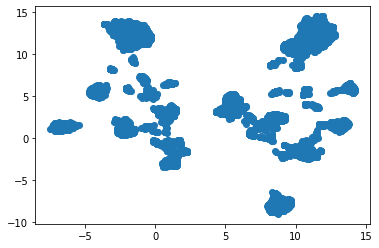

In [132]:
plt.scatter(emb[:,0], emb[:,1])

In [133]:
cluster_df = hdb_dbcv(emb)

100%|██████████| 11/11 [01:22<00:00,  7.46s/it]

     min_sample  min_cluster cluster_selection          m  num_clusters  \
176          40          250               eom  euclidean            17   
17            5          250               eom  manhattan            16   
13            5          200               eom  manhattan            16   
24            5          350               eom  euclidean            15   
12            5          200               eom  euclidean            15   

     unclustered_prop      dbcv  
176          0.028043  0.519238  
17           0.038551  0.516847  
13           0.038551  0.516847  
24           0.035685  0.508286  
12           0.035685  0.508286  


In [134]:
cluster = hdbscan.HDBSCAN(min_cluster_size = 250, min_samples = 40)
labels = cluster.fit_predict(emb)
print(len((set(labels))))

17


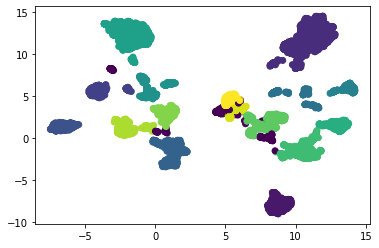

In [135]:
plt.scatter(emb[:,0], emb[:,1], c=labels)

In [136]:
df_2016_clean['labels'] = labels

In [137]:
eth = df_2016_clean.groupby(['labels', 'Eth7'])['Eth7'].sum()

In [138]:
heat = pd.crosstab(df_2016_clean['labels'], df_2016_clean['Eth7'], normalize='index')

In [139]:
heat

Eth7,1.0,2.0,3.0,4.0,5.0,6.0,7.0
labels,,,,,,,
-1,0.537713,0.121655,0.051095,0.026764,0.199513,0.029197,0.034063
0,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.994143,0.001830,0.001830,0.000732,0.000000,0.000732,0.000732
2,0.000000,0.001475,0.855457,0.000000,0.002950,0.140118,0.000000
3,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.635988,0.124095,0.129266,0.045502,0.012410,0.034126,0.018614
5,0.000000,0.000000,0.000000,0.000000,0.286638,0.364224,0.349138
6,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
7,0.320490,0.091068,0.127846,0.378284,0.033275,0.033275,0.015762


In [140]:
ethnic_dist = df_2016_clean['Eth7'].value_counts(normalize=True)

In [148]:
ethnic_dist

Eth7
1.0    0.567276
2.0    0.165188
3.0    0.126296
4.0    0.064820
6.0    0.030022
7.0    0.026269
5.0    0.020128
Name: proportion, dtype: float64

In [141]:
overall = heat / ethnic_dist # have scaled the df for obs by ethinic pop

In [142]:
overall

Eth7,1.0,2.0,3.0,4.0,5.0,6.0,7.0
labels,,,,,,,
-1,0.947886,0.736459,0.404563,0.412898,9.912095,0.972528,1.296704
0,0.000000,6.053697,0.000000,0.000000,0.000000,0.000000,0.000000
1,1.752486,0.011079,0.014491,0.011294,0.000000,0.024384,0.027868
2,0.000000,0.008929,6.773410,0.000000,0.146553,4.667203,0.000000
3,0.000000,6.053697,0.000000,0.000000,0.000000,0.000000,0.000000
4,1.121125,0.751234,1.023511,0.701969,0.616521,1.136711,0.708599
5,0.000000,0.000000,0.000000,0.000000,14.240561,12.131975,13.290820
6,0.000000,0.000000,0.000000,15.427368,0.000000,0.000000,0.000000
7,0.564964,0.551300,1.012269,5.835922,1.653145,1.108359,0.600014


<Axes: xlabel='Eth7', ylabel='labels'>

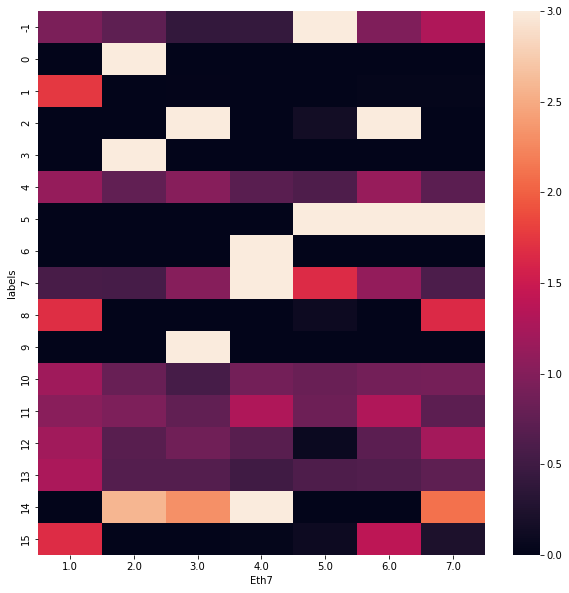

In [143]:
plt.figure(figsize=(10,10))
sns.heatmap(
    overall,
    xticklabels = heat.columns,
    yticklabels = heat.index,
    vmax=3
)

In [ ]:
df_2016_clean['MEMS7_ALL'] = np.log1p(mems) # applied log transformation to mems to protect against skewed dist
df_2016_clean.columns

Index(['Gend3', 'Disab3', 'Age9', 'Eth7', 'NSSEC5', 'Educ6', 'IMD10', 'nchild',
       'VolAny', 'Motiva_POP', 'motivb_POP', 'motivc_POP', 'motivd_POP',
       'WorkStat10', 'labels', 'MEMS7_ALL'],
      dtype='str')

In [146]:
cluster_profiles = df_2016_clean.groupby('labels').agg({
    'Gend3' : 'mean',
    'Disab3' : 'mean',
    'Age9' : 'mean',
    'NSSEC5' : 'mean',
    'Educ6' : 'mean',
    'IMD10' : 'mean',
    'nchild' : 'mean',
    'WorkStat10' : 'mean',
    'Motiva_POP' : 'mean',
    'motivb_POP' : 'mean',
    'motivc_POP' : 'mean',
    'motivd_POP' : 'mean',
    'MEMS7_ALL' : 'mean'
})

<Axes: >

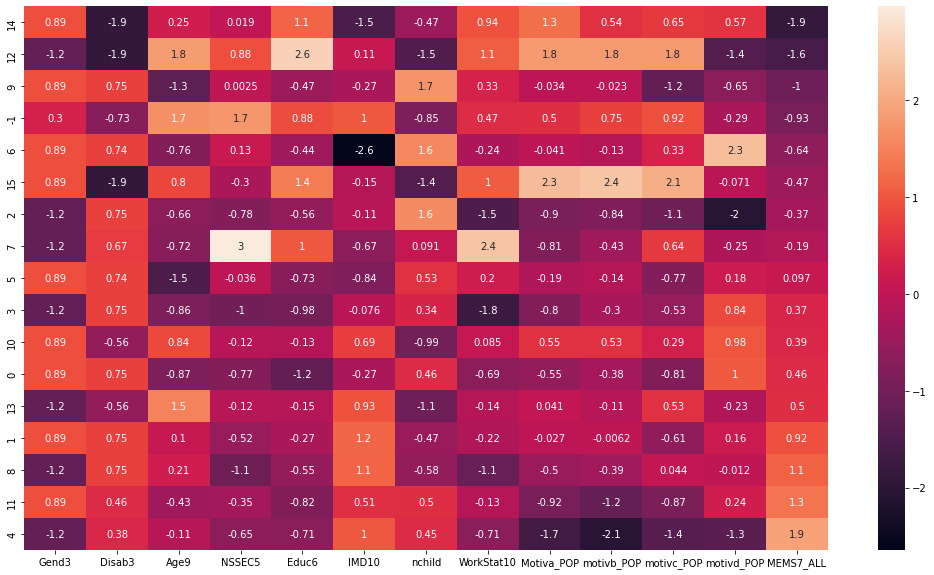

In [147]:
scaler = StandardScaler()
sorted_cluster_profiles = cluster_profiles.sort_values('MEMS7_ALL')
heat = scaler.fit_transform(sorted_cluster_profiles)
plt.figure(figsize=(18,10))
sns.heatmap(
    heat, 
    annot=True,
    xticklabels = sorted_cluster_profiles.columns,
    yticklabels = sorted_cluster_profiles.index
)